# Исследование рынка инвестиций
## Введение
Финансовая компания, работающая с венчурными инвестициями, хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. Для этого необходимо провести исследование на исторических данных. Мы поработаем с информацией о компаниях, объёмах и типах привлечённых инвестиций, а также с дополнительной статистикой по возвратам средств.

## Цель и задачи
**Цель:** подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий.

**Задачи:**
1. Познакомиться с данными и предобработать их.
2. Сделать инжиниринг признаков.
3. Проанализировать выбросы.
4. Проанализировать динамику показателей.
5. Сделать итоговые выводы и рекоммендации.

## Данные
Для анализа поступили данные о рынке инвестиций. Данные состоят из двух датасетов:
- `cb_investments` - информация о компаниях и состоявшемся финансировании
- `cb_returns` - информация об объёмах возвратов по годам и типам финансирования в миллионах долларов

### Данные датасета `cb_investments`:
- `name` — название компании; 
- `homepage_url` — ссылка на сайт компании;
- `category_list` — категории, в которых работает компания. Указываются через |;
- `market` — основной рынок или отрасль компании;
- `funding_total_usd` — общий объём привлечённых инвестиций в долларах США;
- `status` — текущий статус компании, например, operating, closed и так далее;
- `country_code` — код страны, например USA;
- `state_code` — код штата или региона, например CA;
- `region` — регион, например SF Bay Area;
- `city` — город, в котором расположена компания;
- `funding_rounds` — общее число раундов финансирования;
- `participants` — число участников в раундах финансирования;
- `founded_at` — дата основания компании;
- `founded_month` — месяц основания в формате YYYY-MM;
- `founded_quarter` — квартал основания в формате YYYY-QN;
- `founded_year` — год основания;
- `first_funding_at` — дата первого финансирования;
- `mid_funding_at` — дата среднего по времени раунда финансирования;
- `last_funding_at` — дата последнего финансирования;
- `seed` — сумма инвестиций на посевной стадии;
- `venture` — сумма венчурных инвестиций;
- `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг;
- `undisclosed` — сумма финансирования нераскрытого типа;
- `convertible_note` — сумма инвестиций через конвертируемые займы;
- `debt_financing` — сумма долгового финансирования;
- `angel` — сумма инвестиций от бизнес-ангелов;
- `grant` — сумма полученных грантов;
- `private_equity` — сумма инвестиций в виде прямых (частных) вложений;
- `post_ipo_equity` — сумма финансирования после IPO;
- `post_ipo_debt` — сумма долгового финансирования после IPO;
- `secondary_market` — сумма сделок на вторичном рынке;
- `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг;
- `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

### Данные датасета `cb_returns`:
- `year` — год возврата средств;
- `seed` — сумма возвратов от посевных инвестиций;
- `venture` — сумма возвратов от венчурных инвестиций;
- `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу;
- `undisclosed` — сумма возвратов нераскрытого типа;
- `convertible_note` — сумма возвратов через конвертируемые займы;
- `debt_financing` — сумма возвратов от долгового финансирования;
- `angel` — сумма возвратов бизнес-ангелам;
- `grant` — сумма возвратов по грантам;
- `private_equity` — сумма возвратов прямых (частных) вложений;
- `post_ipo_equity` — сумма возвратов от IPO;
- `post_ipo_debt` — сумма возвратов от долгового IPO;
- `secondary_market` — сумма возвратов от сделок на вторичном рынке;
- `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### Структура проекта


## 1. Знакомство с данными: загрузка и предобработка
### 1.1 Вывод общей информации
Загрузим необходимые для работы библиотеки.

In [163]:
!pip install phik

In [164]:
# библиотека для анализа и обработки данных
import pandas as pd
import numpy as np

# библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# библиотека для расчета коэффициента корреляции phik
from phik import phik_matrix

Загрузим данные датасетов `cb_investments` и `cb_returns` в переменные `df` и `df_returns`. 

In [165]:
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
df_returns = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

Познакомимся с датасетом `cb_investments`. Выведем первые 5 строк датасета.

In [166]:
# установим параметр, чтобы отобразились все столбцы
pd.set_option('display.max_columns', None)

# выведем первые 5 строк
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Выведем основную информацию о датасете `cb_investments`.

In [167]:
# выведем основную информацию с помощью метода info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Датасет `cb_investments` содержит `54294` строк и `40` столбцов, в которых хранится информация о компаниях и состоявшемся финансировании. После первичного анализа можно сделать следующие выводы:
- данные соответствуют описанию
- в названиях столбцов `market` и `funding_total_usd` содержатся лишние пробелы, которые нужно удалить для удобства
- стоит привести все названия столбцов к нижнему регистру
- во всех столбцах содержатся пропуски
- в столбце `funding_total_usd` стоит изменить тип данных с `object` на `float`, т.к в нем содержатся числовые данные
- в столбцах `founded_at`, `founded_month`, `first_funding_at`, `mid_funding_at`, `last_funding_at` стоит изменить тип данных с `object` на `datetime64`, т.к. в них содержатся даты
- в столбце `founded_year` стоит изменить тип данных с `float64` на `int`, т.к. год не может быть дробным числом

Далее аналогично познакомимся с датасетом `cb_returns`. 

In [168]:
# выведем первые 5 строк датасета
df_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [169]:
# выведем основную информацию с помощью метода info()
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


В датасете `cb_returns` содержится `15` строк и `14` столбцов, в которых хранится информация об объёмах возвратов по годам и типам финансирования в миллионах долларов. После первичного анализа можно сделать следующие выводы:
- данные соответствуют описанию
- названия столбцов записаны в удобном формате
- в датасете не содержится пропусков
- типы данных подобраны оптимально

### 1.2 Предобработка данных
Запишем в переменную количество строк в датасете до предобработки.

In [170]:
df_len = df.shape[0]

Удалим лишние пробелы в названиях столбцов и приведем все названия к нижнему регистру.

In [171]:
# удаляем лишние пробелы в начале и в конце
df.columns = df.columns.str.strip()

# приводим названия к нижнему регистру
df.columns = df.columns.str.lower()

# проверяем результат
df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

Посмотрим на уникальные значения столбца `market`.

In [172]:
df['market'].unique()

array([' Education ', nan, ' Business Services ', ' Social Media ',
       ' Hardware + Software ', ' Biotechnology ', ' Hardware + Software',
       ' Utilities ', ' Hospitality ', ' Enterprise Software ',
       ' Manufacturing ', ' Pharmaceuticals ', 'Finance', 'Shipping',
       ' Finance ', ' Design ', ' Nonprofits ', ' Software ',
       ' Curated Web ', ' Health Care ', ' Education',
       ' Health and Wellness ', ' Media ', ' Politics ',
       ' Clean Technology ', 'Manufacturing', ' Financial Services ',
       ' Consumer Electronics ', ' Web Hosting ', 'E-Commerce',
       ' Automotive ', ' Local Businesses ', ' E-Commerce ', ' Medical ',
       ' Fashion ', ' Advanced Materials ', ' Banking ', 'Security ',
       ' Publishing ', ' Networking ', ' Analytics ', ' Semiconductors ',
       ' Public Relations ', ' Energy ', ' Cosmetics ', ' Jewelry ',
       ' Nanotechnology ', ' Travel ', ' Retail',
       ' Public Transportation ', 'Consulting ', ' Security ',
       ' Constr

В данные содержатся лишние пробелы, удалим их.

In [173]:
# удалим пробелы
df['market'] = df['market'].str.strip()

# проверим результат
df['market'].unique()

array(['Education', nan, 'Business Services', 'Social Media',
       'Hardware + Software', 'Biotechnology', 'Utilities', 'Hospitality',
       'Enterprise Software', 'Manufacturing', 'Pharmaceuticals',
       'Finance', 'Shipping', 'Design', 'Nonprofits', 'Software',
       'Curated Web', 'Health Care', 'Health and Wellness', 'Media',
       'Politics', 'Clean Technology', 'Financial Services',
       'Consumer Electronics', 'Web Hosting', 'E-Commerce', 'Automotive',
       'Local Businesses', 'Medical', 'Fashion', 'Advanced Materials',
       'Banking', 'Security', 'Publishing', 'Networking', 'Analytics',
       'Semiconductors', 'Public Relations', 'Energy', 'Cosmetics',
       'Jewelry', 'Nanotechnology', 'Travel', 'Retail',
       'Public Transportation', 'Consulting', 'Construction',
       'Real Estate', 'Environmental Innovation', 'Restaurants',
       'Services', 'Technology', 'Telecommunications', 'Insurance',
       'Information Technology', 'Legal',
       'Health Care Info

В столбце `funding_total_usd` удалим выделение разрядов запятыми и приведем к типу `float`.

In [174]:
# удалям запятые
df['funding_total_usd'] = df['funding_total_usd'].str.replace(',', '')

# проверяем результат
df['funding_total_usd'].head(15)

0      90000000 
1       2000000 
2       9000000 
3       7700000 
4        540000 
5      19000000 
6      12000000 
7       8700000 
8       6000000 
9       3500000 
10     28000000 
11      2705000 
12      8900000 
13          -   
14      8000000 
Name: funding_total_usd, dtype: object

В столбце `funding_total_usd` помимо пропусков и числовых значений есть значение `-`, возможно оно означает, что общий объём привлеченных инвестиций равен 0. Посмотрим на строки, где есть этот символ.

In [175]:
# выведем 5 строк, где значение funding_total_usd равно "-   "
df[df['funding_total_usd'] == ' -   '].head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
13,University of Rochester,http://www.rochester.edu,NaN,NaN,-,operating,USA,NY,"Rochester, New York",Rochester,1.0,NaN,1850-01-01,NaN,NaN,1850.0,2014-08-12,NaN,2014-08-12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15,FKK Corporation,http://www.fkk-corporation.com,|Hardware + Software|,Hardware + Software,-,operating,JPN,NaN,Kyoto,Kyoto-shi,1.0,0.0,1854-02-01,NaN,NaN,1854.0,1995-01-01,1995-01-01,1995-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,Laclede Group,http://www.thelacledegroup.com,|Utilities|,Utilities,-,operating,USA,MO,St. Louis,St Louis,1.0,NaN,1857-01-01,NaN,NaN,1857.0,2014-08-12,NaN,2014-08-12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27,Bayer AG,http://bayer.com,|Pharmaceuticals|Biotechnology|,Pharmaceuticals,-,acquired,DEU,NaN,Leverkusen,Leverkusen,1.0,NaN,1863-01-01,NaN,NaN,1863.0,2014-04-13,NaN,2014-04-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
35,Asia Pacific Marine Container Lines,http://AsiaPacificMarine.com,|Logistics Company|Shipping Broker Industry|Sh...,Shipping,-,operating,CAN,BC,Vancouver,Vancouver,1.0,3.0,1870-01-05,NaN,NaN,1870.0,1998-09-01,1998-09-01,1998-09-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Можно заметить, что значения в остальных столбцах с суммами инвестий равны 0, значит можно предположить что `-` действительно означает нулевую сумму. Удалим все строки с `-`, т.к. они не содержат данных о финансировании.

In [176]:
# удаляем строки с "-"
df = df[df['funding_total_usd'] != ' -   ']
print(f'Было удалено {df_len-df.shape[0]} строк.')

# преобразуем тип данных во всем столбце к типу float, используем параметр downcast, чтобы подобрать оптимальную разрядность
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], downcast = 'float')

# проверяем преобразование
df['funding_total_usd'].dtypes

Было удалено 8531 строк.


dtype('float64')

Далее изменим тип данных на дату в столбцах `founded_at, founded_month, first_funding_at, mid_funding_at, last_funding_at`. Начнем со столбца `founded_at`.

In [177]:
# напишем функцию, которая преобразует к формату datetime64, а если нельзя преобразовать, то заменяет на -1
def change(row):
    try:
        return pd.to_datetime(row['founded_at'], format = '%Y-%m-%d')
    except:
        return -1

# применим функцию ко всем строкам датафрейма
df['founded_at'] = df.apply(change, axis = 1)

# посчитаем, в скольких строках не удалось преобразовать дату
print(f'Не удалось изменить формат в {df[df['founded_at'] == -1].shape[0]} стр.')

Не удалось изменить формат в 1 стр.


Формат не удалось изменить только в 1 строке. Удалим ее, т.к. много данных мы не потеряем.

In [178]:
# оставляем строки, где дата не равна -1
df = df[df['founded_at']!=-1]

# меняем тип данных всего столбца
df['founded_at'] = pd.to_datetime(df['founded_at'])

Преобразуем данные в столбцах `first_funding_at, mid_funding_at, last_funding_at`.

In [179]:
# напишем функцию, которая преобразует к формату datetime64, а если нельзя преобразовать, то заменяет на -1
def change(row):
    try:
        return pd.to_datetime(row['first_funding_at'], format = '%Y-%m-%d')
    except:
        return -1
# применим функцию ко всем строкам датафрейма
df['first_funding_at'] = df.apply(change, axis = 1)
# посчитаем, в скольких строках не удалось преобразовать дату
print(f'Не удалось изменить формат в first_funding_at в {df[df['first_funding_at'] == -1].shape[0]} стр.')

# аналогично для mid_funding_at
def change(row):
    try:
        return pd.to_datetime(row['mid_funding_at'], format = '%Y-%m-%d')
    except:
        return -1

df['mid_funding_at'] = df.apply(change, axis = 1)

print(f'Не удалось изменить формат в mid_funding_at в {df[df['mid_funding_at'] == -1].shape[0]} стр.')

# аналогично для last_funding_at
def change(row):
    try:
        return pd.to_datetime(row['last_funding_at'], format = '%Y-%m-%d')
    except:
        return -1

df['last_funding_at'] = df.apply(change, axis = 1)
print(f'Не удалось изменить формат в last_funding_at в {df[df['last_funding_at'] == -1].shape[0]} стр.')

Не удалось изменить формат в first_funding_at в 2 стр.
Не удалось изменить формат в mid_funding_at в 0 стр.
Не удалось изменить формат в last_funding_at в 0 стр.


Удалим строки, в которых не удалось преобразовать формат.


In [180]:
# удаляем строки где дата = -1
df = df[df['first_funding_at'] != -1]
df = df[df['last_funding_at'] != -1]

# меняем тип данных всего столбца
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'])
df['last_funding_at'] = pd.to_datetime(df['last_funding_at'])

Далее преобразуем поля `founded_month`.

In [181]:
df['founded_month'] = pd.to_datetime(df['founded_month'], format = '%Y-%m')

In [182]:
# проверим результат изменений типов данных
df.dtypes

name                            object
homepage_url                    object
category_list                   object
market                          object
funding_total_usd              float64
status                          object
country_code                    object
state_code                      object
region                          object
city                            object
funding_rounds                 float64
participants                   float64
founded_at              datetime64[ns]
founded_month           datetime64[ns]
founded_quarter                 object
founded_year                   float64
first_funding_at        datetime64[ns]
mid_funding_at          datetime64[ns]
last_funding_at         datetime64[ns]
seed                           float64
venture                        float64
equity_crowdfunding            float64
undisclosed                    float64
convertible_note               float64
debt_financing                 float64
angel                    

Далее посмотрим на пропуски.


In [183]:
# выводим абсолютное количество пропусков
df.isna().sum()

name                     4857
homepage_url             7170
category_list            7359
market                   7359
funding_total_usd        4856
status                   5961
country_code             8675
state_code              20143
region                   8675
city                     9361
funding_rounds           4856
participants            18430
founded_at              13562
founded_month           13627
founded_quarter         13627
founded_year            13562
first_funding_at         4856
mid_funding_at          18530
last_funding_at          4856
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_a                  4856
round_b   

In [184]:
# выводим количество пропусков в процентах
(df.isna().sum()/df.shape[0])*100

name                    10.614073
homepage_url            15.668706
category_list           16.081731
market                  16.081731
funding_total_usd       10.611888
status                  13.026661
country_code            18.957605
state_code              44.018794
region                  18.957605
city                    20.456731
funding_rounds          10.611888
participants            40.275350
founded_at              29.637238
founded_month           29.779283
founded_quarter         29.779283
founded_year            29.637238
first_funding_at        10.611888
mid_funding_at          40.493881
last_funding_at         10.611888
seed                    10.611888
venture                 10.611888
equity_crowdfunding     10.611888
undisclosed             10.611888
convertible_note        10.611888
debt_financing          10.611888
angel                   10.611888
grant                   10.611888
private_equity          10.611888
post_ipo_equity         10.611888
post_ipo_debt 

Удалим строки, в которых все значения пропущены.

In [185]:
# сохраним в переменную новую длину датасета
df_new_len = df.shape[0]

# используем метод dropna и параметр all, чтобы удалить строки, где все значения пропущены
df = df.dropna(how = 'all')

# сохраним в переменную кол-во пустых удаленных строк
dropped = df_new_len - df.shape[0]
print(f'Было удалено {dropped} строк.')

Было удалено 4856 строк.


Снова посмотрим на процент пропусков.

In [186]:
(df.isna().sum()/df.shape[0])*100

name                     0.002445
homepage_url             5.657148
category_list            6.119206
market                   6.119206
funding_total_usd        0.000000
status                   2.701447
country_code             9.336495
state_code              37.372873
region                   9.336495
city                    11.013593
funding_rounds           0.000000
participants            33.185019
founded_at              21.283982
founded_month           21.442891
founded_quarter         21.442891
founded_year            21.283982
first_funding_at         0.000000
mid_funding_at          33.429493
last_funding_at          0.000000
seed                     0.000000
venture                  0.000000
equity_crowdfunding      0.000000
undisclosed              0.000000
convertible_note         0.000000
debt_financing           0.000000
angel                    0.000000
grant                    0.000000
private_equity           0.000000
post_ipo_equity          0.000000
post_ipo_debt 

В столбце `funding_rounds` теперь нет пропусков, поэтому поменяем тип данных на `int`.

In [187]:
df['funding_rounds'] = pd.to_numeric(df['funding_rounds'], downcast = 'integer')
df['funding_rounds'].dtype

dtype('int8')

В столбце `mid_funding_at` около 40% пропусков. Заполним пропуски в значениях на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмём приблизительно середину интервала между этими двумя датами.

In [188]:
# прибавляем к началу интервала половину его длины, чтобы получить середину
df['mid_funding_at'] = df['mid_funding_at'].fillna(pd.to_datetime(df['first_funding_at'] + round((df['last_funding_at'] - df['first_funding_at'])/2)))

In [189]:
(df.isna().sum()/df.shape[0])*100

name                     0.002445
homepage_url             5.657148
category_list            6.119206
market                   6.119206
funding_total_usd        0.000000
status                   2.701447
country_code             9.336495
state_code              37.372873
region                   9.336495
city                    11.013593
funding_rounds           0.000000
participants            33.185019
founded_at              21.283982
founded_month           21.442891
founded_quarter         21.442891
founded_year            21.283982
first_funding_at         0.000000
mid_funding_at           0.000000
last_funding_at          0.000000
seed                     0.000000
venture                  0.000000
equity_crowdfunding      0.000000
undisclosed              0.000000
convertible_note         0.000000
debt_financing           0.000000
angel                    0.000000
grant                    0.000000
private_equity           0.000000
post_ipo_equity          0.000000
post_ipo_debt 

В поле `market` заменим пропуски на "Нет информации.

In [190]:
df['market'] = df['market'].fillna('Нет информации')

Остальные пропуски мы не будем удалять, чтобы не потерять важную информацию. Заменять пропуски на заглушки мы тоже не будем, т.к. это может только помешать при дальнейшем анализе.

Далее посмотрим на дубликаты в данных.

In [191]:
df.duplicated().sum()

np.int64(0)

В датасете нет явных дубликатов. 

Посчитаем, какой процент строк мы удалили в процессе предобработки.

In [192]:
f'Было удалено {df_len - df.shape[0]} строк, это {(df_len - df.shape[0])/df_len * 100} % всех данных. {dropped/df_len * 100} % были полностью пустыми. Осталось {df.shape[0]} строк.'

'Было удалено 13390 строк, это 24.662025269827236 % всех данных. 8.943898036615463 % были полностью пустыми. Осталось 40904 строк.'

Далее перейдем к датасету `cb_returns`.

Сделаем столбец `year` индексом.

In [193]:
# устанавливаем год индексом
df_returns = df_returns.set_index('year')

# проверим
df_returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Благодаря первоначальному анализу мы поняли, что пропусков в датасете нет, проверим дубликаты.

In [194]:
df_returns.duplicated().sum()

np.int64(0)

Дубликатов нет. 

---
#### В ходе предобработки мы сделали следующее: 
В датасете `cb_investments`:
- привели названия столбцов к единому стилю
- удалили лишние пробелы в столбце `market`
- привели столбец `funding_total_usd` к типу `float64`
- привели столбцы `founded_at, founded_month, first_funding_at, mid_funding_at, last_funding_at` к типу `datetime64`
- удалили полностью пустые строки
- удалили строки в которых нет информации о финансировании
- удалили строки, в которых не удалось преобразовать дату к формату `datetime64`
- привели столбец `funding_rounds` к типу `int8`
- заменили пропуски в `mid_funding_at` на середину интервала между `first_funding_at` и `last_funding_at`
- заменили пропуски в `market` на 'Нет информации'
- проверили явные дубликаты в данных (их нет)

Всего было удалено 13390 строк, это примерно 25% всех данных. 9% строк были полностью пустыми, так что можно считать что удалили примерно 16% данных. В датасете осталось 40904 строк, этих данных достаточно для решения задач проекта.
  
В датасете `cb_returns`:
- сделали столбец `year` индексом
- проверили явные дубликаты в данных (их нет)

Строки не удаляли.

---

## 2. Инжиниринг признаков
### 2.1. Группы по срокам финансирования
Разделим все компании на три группы:
- Единичное финансирование — был всего один раунд финансирования.
- Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.
- Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:
- По количеству компаний: какой процент от общего числа компаний относится к каждой из трёх групп.
- По объёму инвестиций: какую долю от общего объёма привлечённых средств получила каждая группа.

In [195]:
# создадим новый столбец, разделяющий компании на 3 группы
def group(row):
    # если был 1 раунд финансирования, присваиваем 1 группу
    if row['funding_rounds'] == 1:
        return 1
    # если между первым и последним раундом финансирования прошло не более года, присваиваем 2 группу
    elif (row['last_funding_at'] - row['first_funding_at']).days <= 365:
        return 2
    # если срок финансирования более года, присваиваем 3 группу
    elif (row['last_funding_at'] - row['first_funding_at']).days > 365:
        return 3

# применяем функцию ко всем строкам датафрейма
df['finance_group'] = df.apply(group, axis = 1)

# проверяем результат
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,finance_group
1,University of New Brunswick,http://www.unb.ca,NaN,Нет информации,2000000.0,operating,NaN,NaN,NaN,NaN,1,NaN,1785-01-01,NaT,NaN,1785.0,2014-05-15,2014-05-15,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,1,1.0,1802-07-19,NaT,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,3,0.0,1817-01-01,NaT,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,1,NaN,1826-01-01,NaT,NaN,1826.0,2014-01-14,2014-01-14,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
5,Xavier University,http://www.xavier.edu/,NaN,Нет информации,19000000.0,operating,USA,OH,Cincinnati,Cincinnati,1,NaN,1831-01-01,NaT,NaN,1831.0,2014-10-23,2014-10-23,2014-10-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


Теперь посчитаем, сколько компаний в каждой группе и какой процент от общего числа компаний относится к каждой из трёх групп.

In [196]:
# выведем количество компаний в каждой группе
df['finance_group'].value_counts().sort_values()

finance_group
2     4501
3    12291
1    24112
Name: count, dtype: int64

In [197]:
# посчитаем какой процент от общего числа компаний относится к каждой из трёх групп
perc = df['finance_group'].value_counts(normalize = True)
perc

finance_group
1    0.589478
3    0.300484
2    0.110038
Name: proportion, dtype: float64

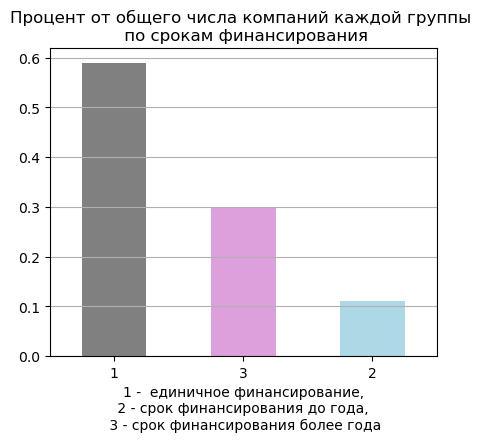

In [198]:
# создадим график, отражающий проценты каждой группы от общего числа компаний
perc.plot(kind = 'bar', rot = 0, figsize = (5, 4), color = ['grey', 'plum', 'lightblue'])

# настраиваем оформление
plt.title('Процент от общего числа компаний каждой группы \n по срокам финансирования')
plt.grid(axis = 'y')
plt.xlabel('1 -  единичное финансирование,\n 2 - срок финансирования до года, \n 3 - срок финансирования более года')

# выводим график
plt.show()

По графику видно, что у большинства компаний (59 %) был всего 1 раунд финансирования. Меньше всего компаний, у которых между первым и последним раундом финансирования прошло не более года (11 %). Примерно у 30 % компаний срок финансирования более года.

Далее посмотрим, какую долю от общего объёма привлечённых средств получила каждая группа.

In [199]:
# посчитаем общую сумму привлеченных средств
total = df['funding_total_usd'].sum()
total

np.float64(650809403144.0)

In [200]:
# посчитаем, какую долю от общего объёма привлечённых средств получила каждая группа
grouped = df.groupby('finance_group')['funding_total_usd'].sum()
grouped
per_1 = grouped.iloc[0]/total*100
per_2 = grouped.iloc[1]/total*100
per_3 = grouped.iloc[2]/total*100
new_df = pd.Series({'1':per_1, '2' : per_2, '3' : per_3} ) 
new_df

1    30.610256
2     7.511566
3    61.878177
dtype: float64

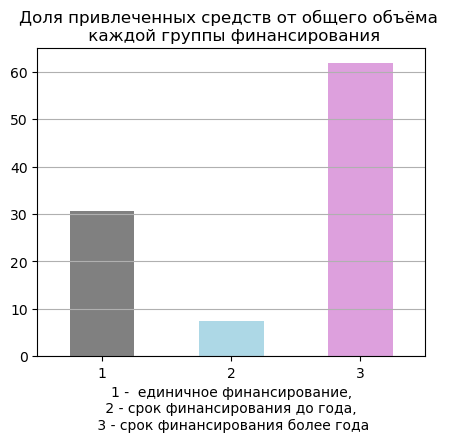

In [201]:
# создадим график, отражающий проценты привлеченных средств от общего объёма каждой группы финансирования
new_df.plot(kind= 'bar', rot = 0, figsize = (5, 4), color = ['grey', 'lightblue', 'plum'])

# настраиваем оформление
plt.title('Доля привлеченных средств от общего объёма \n каждой группы финансирования')
plt.grid(axis = 'y')
plt.xlabel('1 -  единичное финансирование,\n 2 - срок финансирования до года, \n 3 - срок финансирования более года')

# выводим график
plt.show()
plt.show()

По графику видно, что самая большая доля привлеченных средств (62 %) у компаний со сроком финансирования более года. Самая маленькая доля (7 %) - у компаний со сроком финансирования до года. Доля привлеченных средств у компаний с единичным финансированием примерно 31 %.

### 2.2. Выделение средних и нишевых сегментов рынка
Компании указывают свой сегмент рынка в столбце market. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [202]:
# посчитаем, как часто встречается каждый из сегментов
dist = df['market'].value_counts()

# преобразуем в датафрейм
dist = pd.DataFrame(dist)
dist = dist.reset_index()

# удаляем компании о которых нет информации
dist = dist[dist['market']!='Нет информации']
dist

,market,count
0,Software,4812
1,Biotechnology,3590
3,Mobile,2344
4,E-Commerce,1866
5,Curated Web,1693
...,...,...
390,Flash Storage,1
391,Project Management,1
392,Portals,1
393,Service Industries,1


Посчитаем, сколько сегментов попадает в каждую из категорий (нишевый, средний, массовый).

In [203]:
niche = 0
mid = 0
mass = 0
for i in dist['count']:
    if i > 120:
        mass += 1
    elif i>35:
        mid+=1
    elif i < 35:
        niche +=1
print(f'niche {niche}\n mid {mid} \n mass {mass}')

niche 289
 mid 57 
 mass 48


Построим график, на котором мы сможем увидеть долю сегментов относящих к массовым / средним / и нишевым.

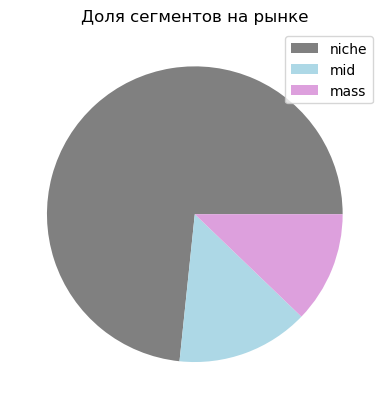

In [204]:
vis = {'niche':289, 'mid':57, 'mass':48}
labels = ['niche', 'mid', 'mass']
vis = pd.Series(vis)
plt.pie(vis, colors = ['grey', 'lightblue', 'plum'])
plt.legend(labels = labels)
plt.title('Доля сегментов на рынке')
plt.show()

Количество сегментов в нишевой категории самое большое (289), ей сильно уступают средняя (57) и массовая (48) категория.


Построим график распределения количества компаний в сегментах.

Text(0.5, 1.0, 'Распределение количества компаний в сегментах')

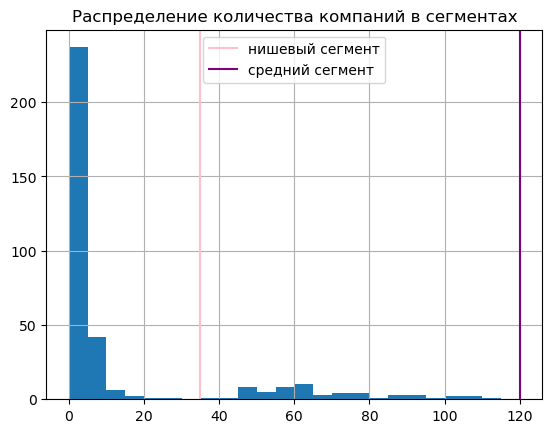

In [205]:
# настроим масштаб
dist.hist(bins = range(0, 125,5))

# обозначим линиями границу нишевого и среднего сегмента
plt.axvline(35, color = 'pink', label = 'нишевый сегмент')
plt.axvline(120, color = 'purple', label = 'средний сегмент' )
plt.legend()
plt.title('Распределение количества компаний в сегментах')

По графику видно, распределение сильно смещено влево - большинство компаний находится в нишевом сегменте. 

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.
Дальнейшие исследования будем выполнять с учётом этой замены.

In [206]:
dist = df['market'].value_counts()

# напишем функцию для классификации сегментом
def segment(row):
    segm = row['market']
    if segm == 'Нет информации':
        return segm
    elif dist[segm] < 35:
        return 'niche'
    elif dist[segm] < 120:
        return 'mid'
    else:
        return row['market']

# применим функцию ко всем строкам датафрейма
df['market'] = df.apply(segment, axis = 1)

In [207]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,finance_group
1,University of New Brunswick,http://www.unb.ca,NaN,Нет информации,2000000.0,operating,NaN,NaN,NaN,NaN,1,NaN,1785-01-01,NaT,NaN,1785.0,2014-05-15,2014-05-15,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,1,1.0,1802-07-19,NaT,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,3,0.0,1817-01-01,NaT,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,1,NaN,1826-01-01,NaT,NaN,1826.0,2014-01-14,2014-01-14,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
5,Xavier University,http://www.xavier.edu/,NaN,Нет информации,19000000.0,operating,USA,OH,Cincinnati,Cincinnati,1,NaN,1831-01-01,NaT,NaN,1831.0,2014-10-23,2014-10-23,2014-10-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


Построим график, на котором мы сможем увидеть долю компании занятых в массовых / средних / и нишевых.

In [208]:
comp_niche = 0
comp_mid = 0
comp_mass = 0

def seg(row):
    global comp_mid, comp_niche, comp_mass 
    market = row['market']
    if market == 'mid':
        comp_mid+=1
    elif market == 'niche':
        comp_niche+=1
    elif market!='Нет информации':
        comp_mass += 1
df.apply(seg, axis = 1)
print(comp_niche, comp_mid, comp_mass)  

830 3839 33732


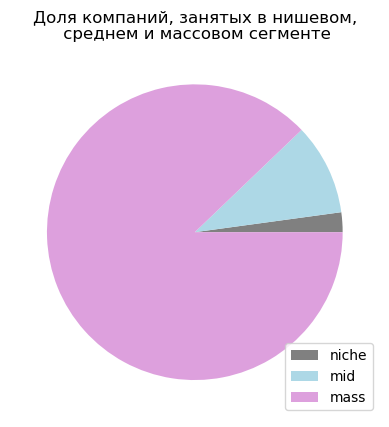

In [209]:
compan = pd.Series({'niche':comp_niche, 'mid':comp_mid, 'mass':comp_mass})
plt.pie(compan, colors = ['grey', 'lightblue', 'plum'])
labels = ['niche', 'mid', 'mass']
plt.legend(labels = labels)
plt.title('Доля компаний, занятых в нишевом,\n среднем и массовом сегменте')
plt.show()

По графику видно, что большинство компаний заняты в массовом сегменте (33732), на втором месте средний сегмент (3839), на последнем нишевый (830).

На рынке стартапов больше всего нишевых сегментов, но притом в нишевых сегментах занято меньше всего компаний. Массовых сегментов на рынке самое маленькое количество, но в них больше всего компаний. Вероятно, за счет этого баланса развивается рынок.

## 3. Работа с выбросами и анализ
### 3.1. Анализируем и помечаем выбросы в каждом из сегментов
Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажем интервал, в котором лежат типичные значения.

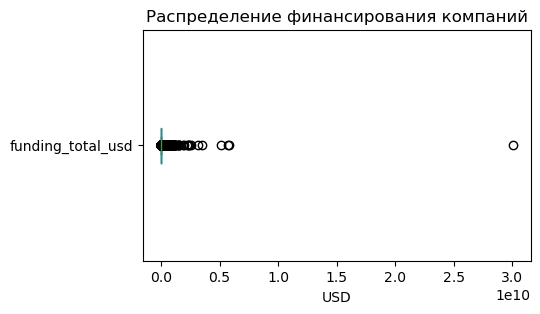

In [210]:
# построим диаграмму размаха по столбцу funding_total_usd
df['funding_total_usd'].plot(kind = 'box', vert = False, figsize = (5,3))
plt.xlabel('USD')
plt.title('Распределение финансирования компаний')
plt.show()

По графику видно, что есть значительные выбросы. Построим диаграмму размаха без выбросов.

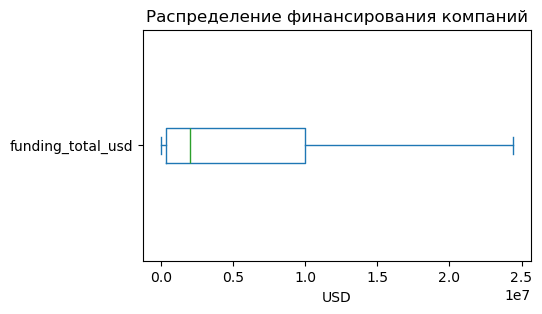

In [211]:
# строим диаграмму размаха без выбросов
df['funding_total_usd'].plot(kind = 'box', vert = False, figsize = (5,3), showfliers = False)
plt.xlabel('USD')
plt.title('Распределение финансирования компаний')
plt.show()

По данному графику без выбросов можно заметить, что большинство значений лежит в интервале примерно от 0 до 25 млн.

Определим компании с аномальным объёмом общего финансирования — используем метод IQR отдельно по каждому сегменту. 

In [212]:
# создаем новый столбец, в котором будет отражаться, является ли аномалией сумма в funding_total_usd для данного сегмента
df['anomaly'] = False

In [213]:
# находим уникальные значения поля markets
markets = df['market'].unique()

# проходимся циклом по всем сегментам
for i in markets:
    # оставляем данные одного сегмента
    new_df = df[df['market'] == i]
    # считаем границы выбросов
    q1 = new_df['funding_total_usd'].quantile(0.25)
    q3 = new_df['funding_total_usd'].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5*iqr
    up = q3 + 1.5*iqr
    # в поле anomaly записываем True, если финансирование компании вышло за границы
    df.loc[(df['market'] == i) & ((df['funding_total_usd'] < low) | (df['funding_total_usd'] > up)), 'anomaly'] = True

In [214]:
# проверим результат
df.head(5)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,finance_group,anomaly
1,University of New Brunswick,http://www.unb.ca,NaN,Нет информации,2000000.0,operating,NaN,NaN,NaN,NaN,1,NaN,1785-01-01,NaT,NaN,1785.0,2014-05-15,2014-05-15,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,False
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,1,1.0,1802-07-19,NaT,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,False
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,3,0.0,1817-01-01,NaT,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,False
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,1,NaN,1826-01-01,NaT,NaN,1826.0,2014-01-14,2014-01-14,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,False
5,Xavier University,http://www.xavier.edu/,NaN,Нет информации,19000000.0,operating,USA,OH,Cincinnati,Cincinnati,1,NaN,1831-01-01,NaT,NaN,1831.0,2014-10-23,2014-10-23,2014-10-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,True


Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [215]:
# выводим какой % компаний сегмента получил аномальное финансирование
grouped = df.groupby('market')['anomaly'].mean()
grouped = grouped * 100
grouped = grouped.sort_values(ascending = False)
grouped

market
Real Estate             17.204301
Entertainment           16.666667
Consulting              16.618911
Search                  16.494845
Cloud Computing         16.447368
Photography             16.176471
SaaS                    16.176471
Technology              15.966387
Video                   15.957447
niche                   15.903614
Travel                  15.454545
Networking              15.384615
Internet                15.352697
Big Data                15.333333
Marketplaces            15.306122
Нет информации          14.902117
mid                     14.482938
E-Commerce              14.415863
Apps                    14.349776
Automotive              14.193548
Medical                 13.907285
Sports                  13.725490
Social Media            13.559322
News                    13.289037
Education               13.285884
Fashion                 13.201320
Mobile                  13.182594
Hospitality             13.095238
Health and Wellness     12.943872
Messagi

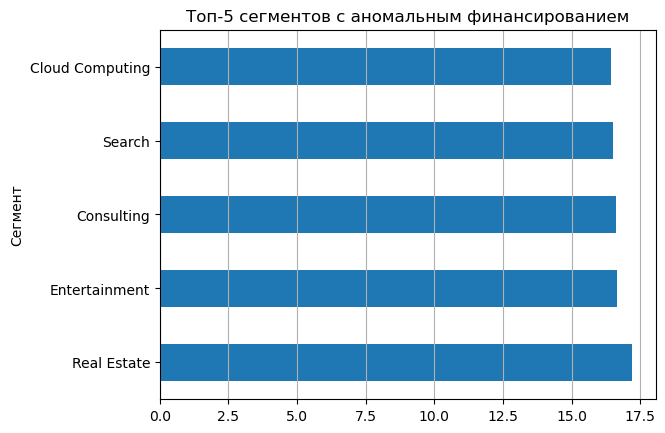

In [216]:
grouped = grouped.head()
grouped.plot(kind = 'barh')
plt.grid(axis = 'x')
plt.ylabel('Сегмент')
plt.title('Топ-5 сегментов с аномальным финансированием')
plt.show()

Самая большая доля компаний с аномальным финансированием находится в сегменте `Real Estate` (18%), в сегментах `Technology Search, Entertainment, Cloud, Computing` примерно одинаковая доля (16%). Самая маленькая доля компаний с аномалиями в сегменте `Semiconductors` - 7 %.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год.

In [217]:
# выведем максимальную дату первого финансирования 
df['first_funding_at'].max()

Timestamp('2014-12-31 00:00:00')

In [218]:
# выведем максимальную дату последнего финансирования
df['last_funding_at'].max()

Timestamp('2014-12-31 00:00:00')

Максимальная дата, о которой есть информация в датасете - 31 декабря 2014 года, последний день года, значит, нам предоставили полные данные за 2014 год.

Исключим из датасета компании, которые мы ранее посчитали получившими аномальное финансирование.

In [219]:
df = df[df['anomaly'] == False]

На основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [220]:
# создадим новый столбец year с годом
df['year'] = df['mid_funding_at'].dt.year

In [221]:
# посчитаем, сколько раундов финансирования было в каждом году
years = df.groupby('year')['funding_rounds'].sum().reset_index()
years

,year,funding_rounds
0,1921,1
1,1960,2
2,1979,1
3,1982,3
4,1983,1
5,1984,2
6,1985,3
7,1987,2
8,1989,1
9,1990,1


In [222]:
# создадим список годов, которые нужно оставить
years = years[years['funding_rounds']>50]['year']
years = list(years)

In [223]:
# удалим из датафрейма строки с годами, которых нет в списке
for i in df['year']:
    if i not in years:
        df = df[df['year'] != i]

In [224]:
# проверим, какие года остались
df['year'].sort_values().unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014], dtype=int32)

Теперь для анализа у нас остались данные за 2000-2014 года, т.к. в эти годы было зафиксировано 50 и более раундов финансирования.
### 3.3. Анализ типов финансирования по объёму и популярности
Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Будем ориентироваться на значения в столбцах `seed, venture, equity_crowdfunding, undisclosed, convertible_note, debt_financing, angel, grant, private_equity, post_ipo_equity, post_ipo_debt, secondary_market, product_crowdfunding.`

In [225]:
# посчитаем, какие суммы привлекли разые типы финансирования
grouped = df[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum().sort_values()
grouped

secondary_market        4.528580e+07
product_crowdfunding    1.860939e+08
equity_crowdfunding     2.379606e+08
post_ipo_debt           2.867183e+08
convertible_note        5.660394e+08
post_ipo_equity         1.946452e+09
grant                   1.978849e+09
undisclosed             2.100352e+09
angel                   2.479764e+09
private_equity          4.825109e+09
debt_financing          8.178153e+09
seed                    9.431332e+09
venture                 1.290820e+11
dtype: float64

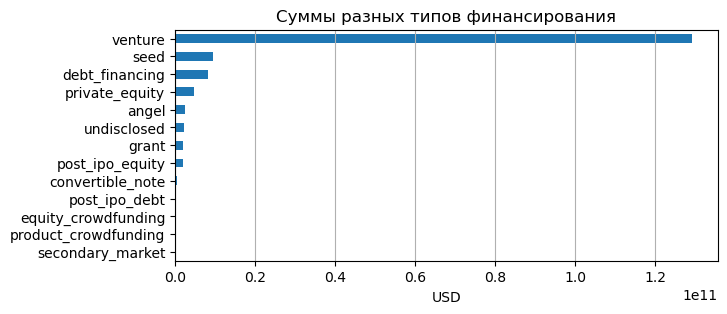

In [226]:
grouped.plot(kind = 'barh', figsize = (7,3))
plt.title('Суммы разных типов финансирования')
plt.xlabel('USD')
plt.grid(axis = 'x')
plt.show()

Видно, что тип финансирования `venture` очень сильно вырывается вперед по сравнению с другими типами. Меньше всего денег привлек тип финансирования `secondary_market`.

Далее построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

In [227]:
# сохраним в список нужные нам столбцы
col = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

In [228]:
# посчитаем, сколько раз встречался каждый тип финансирования
sp = []
for i in col:
    sp.append(df[df[i] != 0 ].shape[0])
sp

[13375, 18819, 515, 813, 521, 3265, 2936, 1003, 633, 164, 27, 7, 204]

In [229]:
data = pd.Series(sp,col)
data = data.sort_values()
data

secondary_market            7
post_ipo_debt              27
post_ipo_equity           164
product_crowdfunding      204
equity_crowdfunding       515
convertible_note          521
private_equity            633
undisclosed               813
grant                    1003
angel                    2936
debt_financing           3265
seed                    13375
venture                 18819
dtype: int64

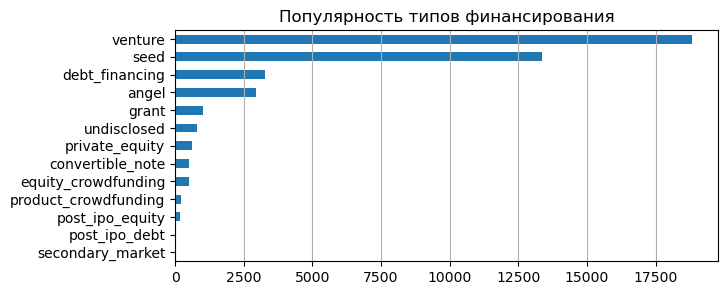

In [230]:
data.plot(kind = 'barh', figsize = (7,3))
plt.title('Популярность типов финансирования')
plt.grid(axis = 'x')
plt.show()

Типы финансирования `grant, equity_crowdfunding, product_crowdfunding` используются часто, при этом характеризуются небольшими объёмами предоставленных сумм.
Типы финансирования `private_equity, post_ipo_equity, post_ipo_debt` встречаются редко, но характеризуются значительным объёмом предоставленных сумм. 
У остальных типов популярность прямо пропорциональна сумме финансирования.

Далее построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [231]:
# посчитаем суммарный обем возвратов для разных типов финансирования
returns = df_returns.sum().sort_values()
returns

grant                       0.00
product_crowdfunding        1.86
equity_crowdfunding         3.83
secondary_market            5.20
convertible_note           34.79
post_ipo_debt              91.03
undisclosed               730.88
post_ipo_equity          1104.96
angel                    1509.23
seed                     2382.24
private_equity           3587.33
debt_financing           4734.85
venture                 40578.62
dtype: float64

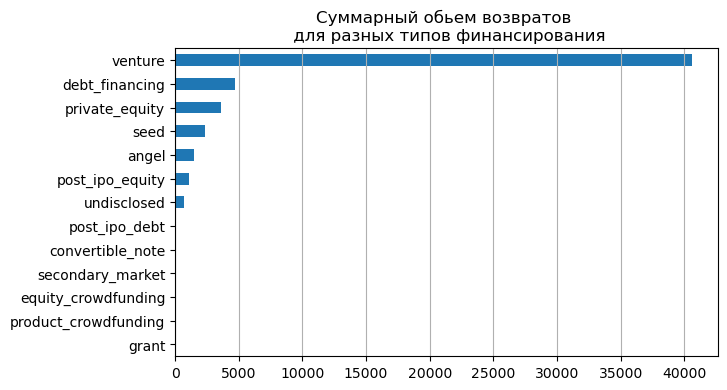

In [232]:
returns.plot(kind = 'barh', figsize = (7,4))
plt.grid(axis = 'x')
plt.title('Суммарный обьем возвратов \n для разных типов финансирования')
plt.show()

Суммарный объем возвратов у `venture` (40579) значительно превышает другие значения. На 2 месте находится категория `debt_financing` (4735), на 3 -  `private_equity` (3587).

Построим еще один график для категорий с суммой возвратов меньше 100, чтобы лучше изучить их.

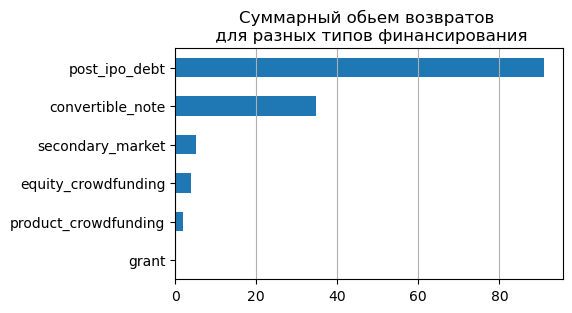

In [233]:
returns.drop(['undisclosed', 'post_ipo_equity', 'angel', 'seed', 'private_equity', 'debt_financing', 'venture']).plot(kind = 'barh', figsize = (5,3))
plt.grid(axis = 'x')
plt.title('Суммарный обьем возвратов \n для разных типов финансирования')
plt.show()

Как мы видим, суммарный объем возвратов для типа финансирования `grant` равен 0. Этот тип финансирования явно стоит избегать.

## 4. Анализ динамики
### 4.1. Динамика предоставления финансирования по годам
Используя столбцы `funding_total_usd` и `funding_rounds`, для каждой компании рассчитаем средний объём одного раунда финансирования.

In [234]:
# создадим новый столбец датафрейма со среднмим объемом раунда финансирования
df['avg_round_sum'] = df['funding_total_usd']/df['funding_rounds']

Построим график, который отразит динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.

In [235]:
grouped = df.groupby('year')['avg_round_sum'].mean()
grouped

year
2000    4.492723e+06
2001    3.366817e+06
2002    4.053461e+06
2003    3.099490e+06
2004    4.616702e+06
2005    5.801089e+06
2006    5.346925e+06
2007    4.678782e+06
2008    4.322739e+06
2009    3.517328e+06
2010    3.188317e+06
2011    2.598340e+06
2012    2.034511e+06
2013    1.976610e+06
2014    2.203065e+06
Name: avg_round_sum, dtype: float64

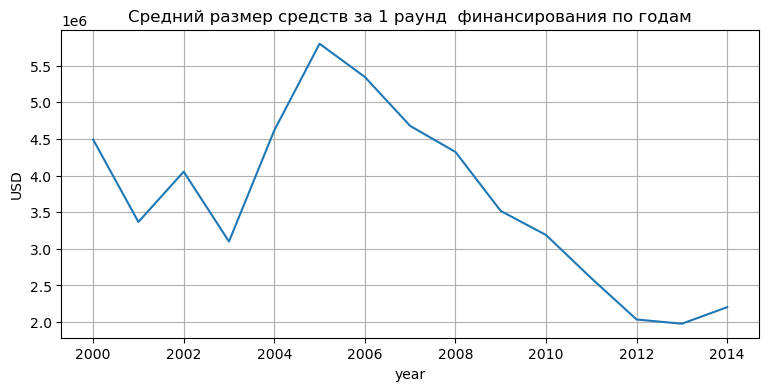

In [236]:
grouped.plot(kind = 'line', figsize = (9, 4))
plt.title('Средний размер средств за 1 раунд  финансирования по годам')
plt.ylabel('USD')
plt.grid()
plt.show()

Типичный размер средств, собранных в рамках одного раунда, был максимальным в 2005 году. Далее размер средств шел на спад до 2013 года. К 2014 снова начал расти.

Построим график, отражающий динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

In [237]:
grouped = df.groupby('year')['funding_rounds'].sum()
grouped

year
2000      113
2001       66
2002       98
2003      125
2004      181
2005      948
2006     1849
2007     2842
2008     3663
2009     4617
2010     6136
2011     7574
2012     9705
2013    12880
2014     7122
Name: funding_rounds, dtype: int64

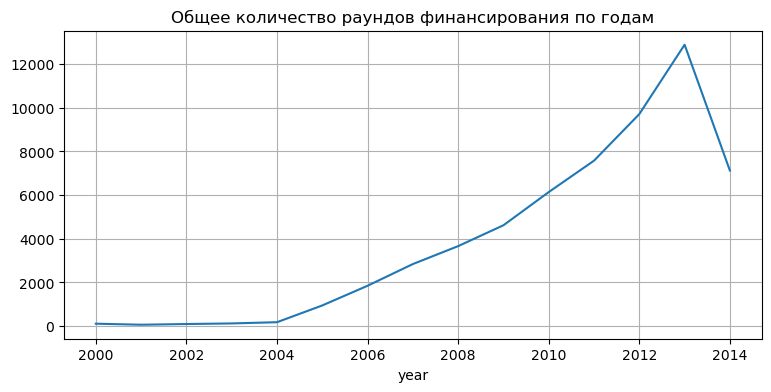

In [238]:
grouped.plot(kind = 'line', figsize = (9,4))
plt.title('Общее количество раундов финансирования по годам')
plt.grid()
plt.show()

Самое большое количество раундов финансирования (12907) было в `2013` году. До 2013 года количество раундов постепенно возрастало. А вот в 2014 году количество раундов уменьшилось, однако средний размер средств за 1 раунд, наоборот, увеличился, по сравнению с 2013 годом.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка.

In [239]:
table = df.pivot_table(index = 'market', columns = 'year', values = 'funding_total_usd', aggfunc = 'sum')
table

year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
Advertising,14470000.0,8778321.0,24500000.0,10500000.0,6000000.0,127196022.0,2.992995e+08,5.567043e+08,6.226735e+08,5.634460e+08,6.316179e+08,4.107307e+08,5.211370e+08,5.249151e+08,2.077923e+08
Analytics,14822803.0,NaN,7500000.0,3840000.0,3000000.0,79014044.0,1.397013e+08,9.882900e+07,2.080778e+08,1.409493e+08,2.537399e+08,4.433334e+08,5.392143e+08,6.228214e+08,1.514616e+08
Apps,NaN,NaN,NaN,NaN,NaN,NaN,1.310600e+06,NaN,4.300000e+06,7.219000e+06,6.123779e+06,1.837407e+07,3.260112e+07,2.886862e+07,6.623773e+07
Automotive,NaN,NaN,NaN,4530000.0,NaN,22500000.0,1.266000e+07,3.771260e+07,5.947864e+07,2.080031e+07,1.769692e+07,7.645216e+07,3.555768e+07,1.175725e+08,6.903416e+07
Big Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.780000e+06,2.452515e+06,5.973750e+05,3.923330e+07,6.036916e+07,8.641334e+07,7.869892e+07,7.923260e+07
Biotechnology,NaN,NaN,NaN,85531178.0,97184859.0,480063583.0,9.035005e+08,1.704078e+09,1.716033e+09,3.915901e+09,4.894500e+09,4.967552e+09,4.931139e+09,5.694270e+09,2.509639e+09
Clean Technology,NaN,NaN,34390435.0,50352939.0,50427954.0,19420000.0,1.314739e+08,7.497112e+08,3.165808e+09,1.963503e+09,1.604429e+09,1.545603e+09,9.580112e+08,1.203061e+09,6.886868e+08
Cloud Computing,11500000.0,NaN,NaN,NaN,NaN,NaN,9.951809e+06,2.035434e+07,4.437500e+07,5.222372e+07,8.525538e+06,7.315140e+07,7.442158e+07,8.484678e+07,7.344086e+07
Consulting,4500000.0,NaN,NaN,NaN,NaN,44862000.0,2.396555e+07,7.034634e+07,1.906108e+07,6.271516e+07,8.126488e+07,4.341340e+07,6.592276e+07,9.332132e+07,5.429802e+07


Отберем только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

In [240]:
# создадим новый столбец, True - если в 2014 суммарное финансирование больше, чем в 2013, False если наоборот
table = pd.DataFrame(table)
def new(row):
    if row[2014] > row[2013]:
        return True
    else:
        return False
table['grow'] = table.apply(new, axis = 1)

In [241]:
# оставим те сегменты, где был положительный рост суммарного финансирования
table = table[table['grow'] == True]
table

year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,grow
market,,,,,,,,,,,,,,,,
Apps,NaN,NaN,NaN,NaN,NaN,NaN,1310600.0,NaN,4300000.0,7219000.0,6123779.0,18374071.0,3.260112e+07,2.886862e+07,6.623773e+07,True
Big Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7780000.0,2452515.0,597375.0,39233297.0,60369158.0,8.641334e+07,7.869892e+07,7.923260e+07,True
Design,NaN,NaN,NaN,NaN,NaN,9300000.0,707000.0,10800000.0,5944302.0,2150144.0,17239975.0,8899967.0,3.963069e+07,6.095884e+07,6.898852e+07,True
Internet,10000000.0,NaN,1100000.0,NaN,10500000.0,1775000.0,5000.0,4495379.0,23412964.0,38195773.0,36657500.0,36859032.0,2.828868e+07,6.973210e+07,1.178308e+08,True
Manufacturing,56659310.0,2368582.0,NaN,4269608.0,3000000.0,61770000.0,163957751.0,147726051.0,173054260.0,422862531.0,244329661.0,561639285.0,5.222052e+08,3.939366e+08,4.163323e+08,True
Medical,24000000.0,NaN,NaN,NaN,NaN,11090000.0,20250000.0,2100000.0,28812744.0,11566200.0,25590338.0,28540962.0,4.403960e+07,6.446942e+07,1.752361e+08,True
Real Estate,2500000.0,NaN,5275000.0,6292200.0,NaN,250000.0,2080000.0,33220000.0,46613100.0,38840213.0,37344608.0,20015128.0,7.732086e+07,9.220766e+07,1.155674e+08,True
SaaS,NaN,NaN,2000000.0,NaN,NaN,5240000.0,4791121.0,14652595.0,27226900.0,13536585.0,32609390.0,32223749.0,4.969991e+07,7.957661e+07,9.280775e+07,True
Startups,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5010387.0,460700.0,2111966.0,19654403.0,1.235878e+07,1.808055e+07,4.150184e+07,True


Построим график, на котором отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у нас достаточно данных (2008-2014). Рассмотрим только массовые сегменты, а средние и нишевые исключим.

In [242]:
# уберем лишние данные
table = table.iloc[:11, 8:15]

# table.plot(kind = 'line')
# plt.show()

In [243]:
# транспонируем, чтобы построить график
table = table.T

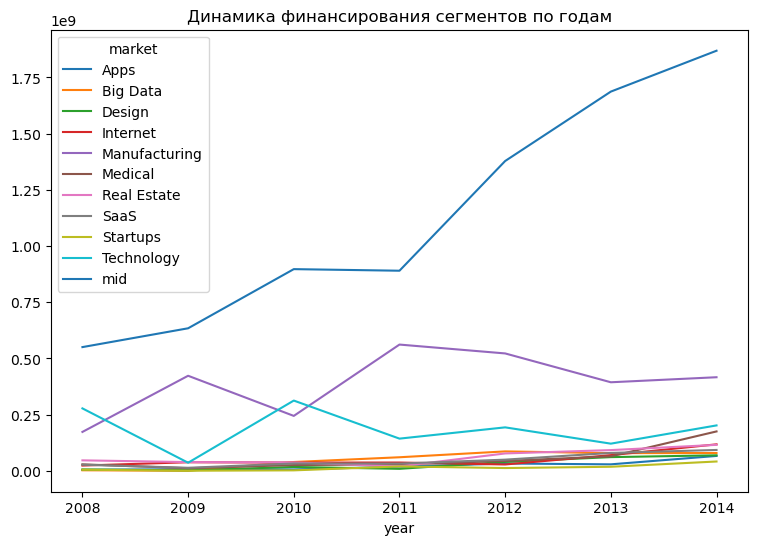

In [244]:
# строим график
table.plot(kind='line', figsize = (9,6))
plt.title('Динамика финансирования сегментов по годам')
plt.show()

У сегмента `Technology` каждый год то резкий рост, то спад. В последние несколько лет сегменты `Apps, Entertainment, Photograhy, Startups, Video` показывают умеренный рост. А сегменты `Internet, Medical, Real Estate` показывают наиболее быстрый и уверенный рост.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования
Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Для каждого года и каждого вида финансирования рассчитаем нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных.

In [245]:
# посчитаем сумму предоставленных средств по годам и типам
new = df.groupby('year')[col].sum()
new

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,1.675914e+07,3.279622e+08,0.0,112202640.0,0.0,1.400000e+07,24086333.0,293114.0,0.000000e+00,3467747.0,0.0,7718867.0,0.0
2001,2.667675e+06,2.175191e+08,0.0,36596784.0,1500000.0,5.829217e+06,1000000.0,100000.0,0.000000e+00,0.0,0.0,0.0,0.0
2002,1.046519e+07,3.069406e+08,0.0,42323731.0,0.0,1.530967e+07,3000000.0,0.0,7.500000e+06,300000.0,0.0,0.0,0.0
2003,1.531836e+07,3.722344e+08,0.0,10280000.0,0.0,1.050000e+06,5629661.0,16850717.0,0.000000e+00,0.0,0.0,0.0,0.0
2004,1.810473e+07,6.641505e+08,0.0,62912359.0,0.0,3.081662e+07,11013741.0,10363600.0,0.000000e+00,0.0,0.0,0.0,0.0
2005,3.942520e+07,4.809711e+09,0.0,8871332.0,0.0,1.017207e+08,60914621.0,6266481.0,5.000000e+06,4796022.0,0.0,0.0,0.0
2006,6.679477e+07,9.020604e+09,933057.0,61545498.0,10702385.0,1.408484e+08,70756153.0,6147500.0,1.782024e+07,0.0,0.0,0.0,0.0
2007,1.922965e+08,1.206209e+10,0.0,109649902.0,14116788.0,2.086016e+08,201152441.0,34237779.0,1.533702e+08,12000000.0,0.0,0.0,0.0
2008,3.020030e+08,1.423473e+10,0.0,119920337.0,28600902.0,4.286221e+08,249299613.0,23485347.0,1.917563e+08,36000000.0,0.0,0.0,1000000.0


Добавим небольшое число, например, 1e-60, чтобы избежать деления на ноль.

In [246]:
new = new + 1e-60

In [247]:
# находим нормированные значения возврата средств
new_df = (df_returns*1000000)/new
new_df

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,0.996471,0.168922,0.000000e+00,0.697042,0.000000e+00,0.618571,0.266956,0.0,0.000000e+00,2.710694e-01,0.000000,2.591054e-02,0.000000
2001,1.079592,0.107991,0.000000e+00,0.587483,6.666667e-03,0.770258,1.180000,0.0,0.000000e+00,4.600000e+65,0.000000,4.600000e+65,0.000000
2002,0.629707,0.682282,0.000000e+00,0.608878,2.000000e+64,0.223388,1.136667,0.0,2.013333e-01,1.133333e+00,0.000000,6.000000e+64,0.000000
2003,0.505276,0.628260,0.000000e+00,0.914397,1.000000e+64,1.038095,0.605720,0.0,1.620000e+66,2.110000e+66,0.000000,8.000000e+64,0.000000
2004,0.548476,0.837009,0.000000e+00,0.527559,1.000000e+64,0.439698,0.833504,0.0,2.190000e+66,3.380000e+66,0.000000,5.500000e+65,0.000000
2005,0.674695,0.546586,0.000000e+00,1.071992,2.000000e+64,0.344964,0.509894,0.0,4.800000e-01,7.318565e-01,0.000000,5.000000e+64,0.000000
2006,0.925372,0.343678,2.036317e-01,0.759438,1.663181e-01,0.803772,0.674853,0.0,9.354530e-01,2.058000e+67,0.000000,1.200000e+65,0.000000
2007,0.366153,0.297243,1.000000e+64,0.504971,2.280972e-01,0.602488,0.817837,0.0,5.790563e-01,2.030000e+00,0.000000,5.700000e+65,0.000000
2008,0.297083,0.190873,3.000000e+64,0.342060,5.978832e-02,0.927484,0.412476,0.0,6.799254e-01,2.341111e+00,0.000000,4.700000e+65,0.000000


Заменим аномально большие значения на пропуски.

In [248]:
def change(row):
    for i in new_df.columns:
        if row[i] > 100000000:
            row [i] = np.nan
    return row
new_df = new_df.apply(change, axis = 1)

Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `'venture', 'debt_financing', 'private_equity', 'seed', 'angel'`.

In [249]:
# оставим только нужные нам для визуализации столбцы
new_df = new_df[['venture', 'debt_financing', 'private_equity', 'seed', 'angel']]

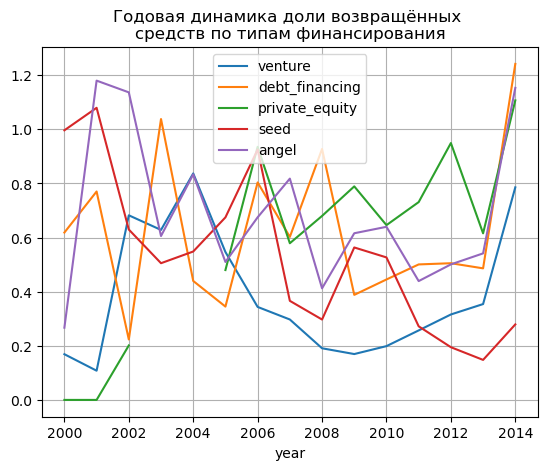

In [250]:
new_df.plot(kind = 'line')
plt.title('Годовая динамика доли возвращённых \nсредств по типам финансирования')
plt.grid()
plt.show()

Во всех типах финансирования наблюдается рост показателя с 2013 по 2014 год, сильнее всего он произошел в типе финансирования `debt_financing`. В `private equity` в последние годы нормированные значения возврата средств выше, чем у других.

## 5. Итоговый вывод и рекомендации
### Обзор проделанной работы
В ходе исследования мы познакомились с историческими данными рынка инвестиций, провели предобработку данных, сделали инжиниринг признаков, проанализировали выбросы, изучили динамику разных показателей.
### Главные выводы
- самая большая доля привлеченных средств (62 %) у компаний со сроком финансирования больше года
- большинство компаний (714) находится в нишевом сегменте, а меньше всего в массовом (53)
- самая большая доля компаний с аномальным финансированием в сегмент `Real_eatate` (18 %)
- в каждом году с 2000 по 2014 было зафиксировано 50 и более раундов финансирования
- самые большие суммы финансирования в сегменте `venture`, который является самым популярным (18819 раз использовался), самые низкие в сегменте `secondary_market`
- суммарный объем возвратов также самый большой в `venture` (40579), `debt_financing` на 2 месте (4735), `private_equity` на 3 (3587), `grant` на последнем (0)
- типичный размер средств, собранный в рамках одного раунда сильно падал с 2005 по 2013 гг., с 2013 по 2014 вырос
- самое большое количество раундов финансирования было в 2013 г. (12907), до 2013 года кол-во раундов росло, с 2013 упало
- сегменты `internet`, `medical`, `Real_estate` показывают наиболее быстрый и уверенный рост сумм финансирования
- сильнее всего выросла доля возвращенных средств в типе финансирования `debt_financing` с 2013 по 2014 г. В `private equity` нормированные значения возврата средств выше, чем у других.
### Рекоммендации

Я бы рекоммендовала инвестировать в отрасль `Real_estate`, т.к. там самая большая доля компаний с аномальным финансированием от 25 млн (18%). Также этот сегмент показывает быстрый и уверенный рост сумм финансирования, а значит, многие богатые инвесторы вкладывают туда деньги, и, вероятно, это выгодно.
Наиболее уместным будет тип инвестирования `debt_financing`, т.к. на конец 2014 года у этого типа была самая высокая доля возвращенных средств.